# **House Price Prediction & Customer Churn Analysis**

- ## Importing modules

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **SECTION A — Data Exploration & Preprocessing**

#### **Q1) a.** Load house_price.csv into a DataFrame. Display the first 5 rows, shape, dtypes, and descriptive statistics (df.describe()). Identify any object/categorical columns.

In [81]:
house_pri = pd.read_csv("house_price.csv")
house_pri.head()

,area_sqft,bedrooms,bathrooms,house_age_years,location_score,has_garage,has_garden,distance_from_city_km,price
0,1360,1,3.0,27,7.8,0,1,34.0,298456
1,4272,1,2.0,14,5.5,0,1,31.4,590271
2,3592,3,2.0,29,5.9,0,1,16.2,532075
3,966,5,2.0,36,9.6,0,1,40.9,268389
4,4926,4,NaN,28,8.6,0,1,25.3,778846


In [82]:
# Shape
house_pri.shape

(500, 9)

In [83]:
#dtpe
house_pri.dtypes

area_sqft                  int64
bedrooms                   int64
bathrooms                float64
house_age_years            int64
location_score           float64
has_garage                 int64
has_garden                 int64
distance_from_city_km    float64
price                      int64
dtype: object

In [84]:
# Describe
house_pri.describe()

,area_sqft,bedrooms,bathrooms,house_age_years,location_score,has_garage,has_garden,distance_from_city_km,price
count,500.000000,500.000000,480.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2805.660000,2.970000,1.995833,24.316000,5.429800,0.694000,0.630000,26.316000,445292.586000
std,1261.356268,1.452349,0.822430,14.438736,2.551304,0.461291,0.483288,13.818225,177221.305591
min,504.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.600000,50000.000000
25%,1666.750000,2.000000,1.000000,12.000000,3.100000,0.000000,0.000000,15.975000,299869.000000
50%,2930.000000,3.000000,2.000000,24.000000,5.500000,1.000000,1.000000,26.850000,451107.000000
75%,3830.750000,4.000000,3.000000,36.000000,7.700000,1.000000,1.000000,37.800000,578470.250000
max,4999.000000,5.000000,3.000000,49.000000,10.000000,1.000000,1.000000,49.800000,861256.000000


In [85]:
# Identifying the object/categorical columns
cate_cols = house_pri.select_dtypes(include=["object"]).columns
cate_cols

Index([], dtype='object')

#### **b.** Check for missing values in every column. For the bathrooms column, fill missing values with the column median. Verify no missing values remain.

In [86]:
# Finding missing values
house_pri.isnull().sum()

area_sqft                 0
bedrooms                  0
bathrooms                20
house_age_years           0
location_score            0
has_garage                0
has_garden                0
distance_from_city_km     0
price                     0
dtype: int64

In [87]:
# Filling the missing values of bathroom with median
from sklearn.impute import SimpleImputer
median_imp = SimpleImputer(strategy= "median")
house_pri["bathrooms"] = median_imp.fit_transform(house_pri[["bathrooms"]])

In [88]:
# Verifying if their any null value remains or not
house_pri.isnull().sum()

area_sqft                0
bedrooms                 0
bathrooms                0
house_age_years          0
location_score           0
has_garage               0
has_garden               0
distance_from_city_km    0
price                    0
dtype: int64

#### **c.** Plot: (i) a histogram of price

Text(0, 0.5, 'Frequency')

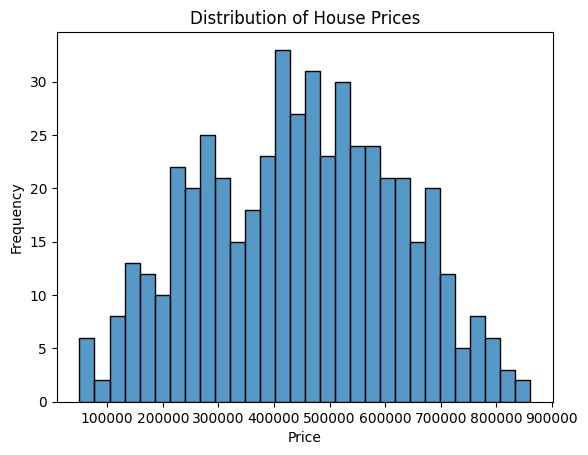

In [89]:
sns.histplot(house_pri["price"], bins = 30)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

#### (ii) a boxplot of area_sqft

Text(0, 0.5, 'Area sqft')

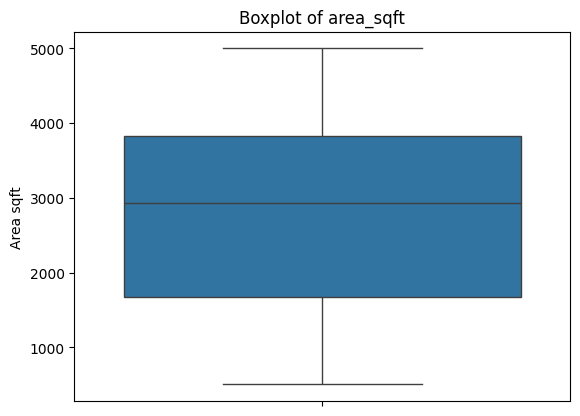

In [90]:
sns.boxplot(house_pri["area_sqft"])
plt.title("Boxplot of area_sqft")
plt.ylabel("Area sqft")

#### (iii) a heatmap of the Pearson correlation matrix for all numeric features. Interpret which features are most correlated with price.

Text(0.5, 1.0, 'Correlation Heatmap')

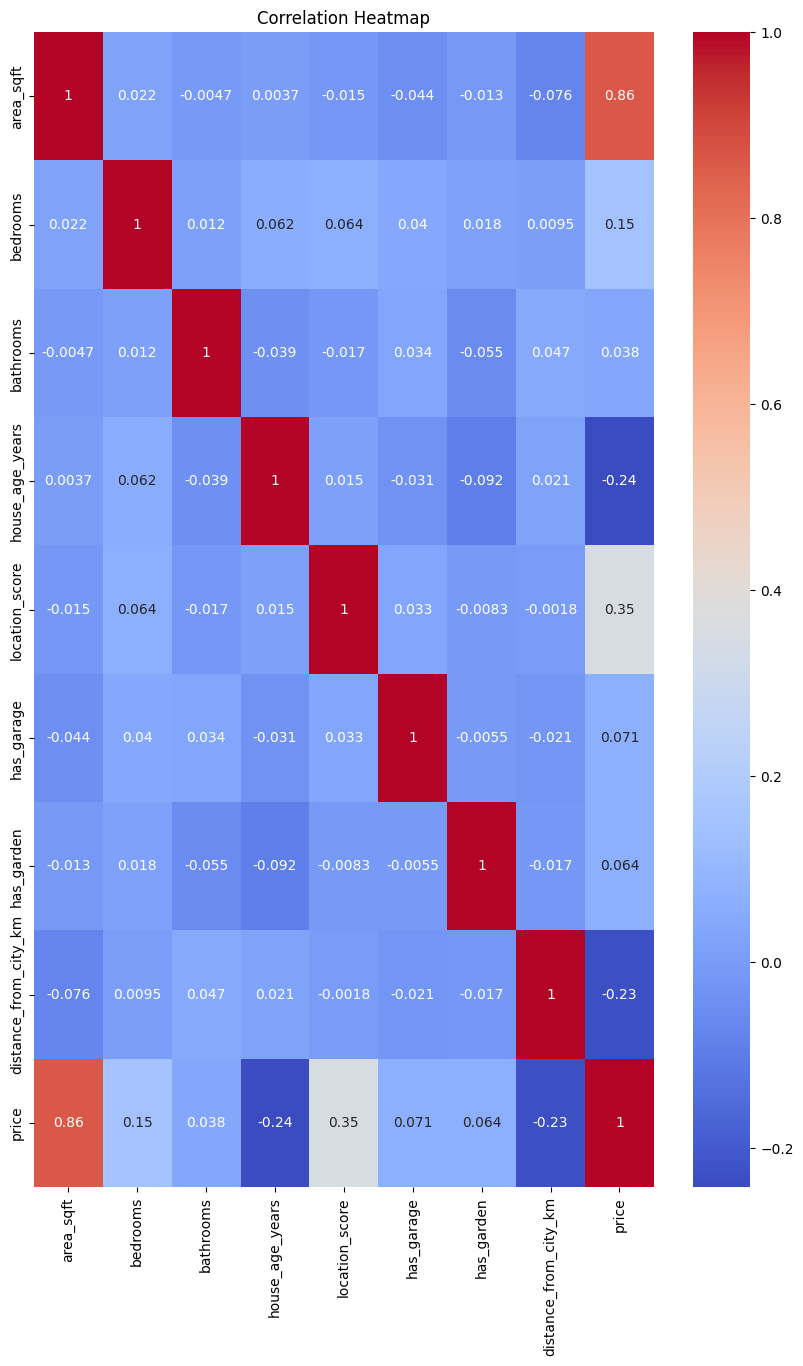

In [91]:
corr = house_pri.corr()

plt.figure(figsize=(10,15))
sns.heatmap(corr, annot = True, cmap= "coolwarm")
plt.title("Correlation Heatmap")

#### **d.**	Detect and remove outliers from the price column using the IQR method (remove rows where price < Q1 - 1.5*IQR or price > Q3 + 1.5*IQR). Print how many rows were removed.

In [92]:
# Calculating Q1 & Q3
q1 = house_pri["price"].quantile(0.25)
q3 = house_pri["price"].quantile(0.75)

# Calculating IQR
IQR = q3-q1

# Defing lower and upper bounds
lower_bound = q1 - 1.5*IQR
upper_bound = q3 - 1.5*IQR

# Counting rows before removal
before_rows = house_pri.shape[0]
print(f"Before Rows: {before_rows}")

# Removing outliers
house_pri = house_pri[(house_pri["price"] >= lower_bound) & (house_pri["price"] <= upper_bound)]

# Count rows after removal

after_rows = house_pri.shape[0]
print(f"After Rows: {after_rows}")
print("Number of rows removed:", before_rows - after_rows)

Before Rows: 500
After Rows: 29
Number of rows removed: 471


#### **Q2) a.** For house_price.csv: Create a new feature price_per_sqft = price / area_sqft. Then apply Label Encoding to any categorical columns if present. Separate features (X) and target (y) and split into 80% train, 20% test using train_test_split(random_state=42).

In [93]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Creating the new feature
house_pri["price_per_sqft"] = house_pri["price"] / house_pri["area_sqft"]

# Already identified categorical columns
print(f"Categorical columns: {cate_cols}")

# Applying label encoder
le = LabelEncoder()

for col in cate_cols:
    house_pri[col] = le.fit_transform(house_pri[col])

# Separating feature(x) and target(y)
x = house_pri.drop("price", axis = 1)
y = house_pri["price"]

# train-test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

Categorical columns: Index([], dtype='object')


#### **b.** Apply StandardScaler to X_train and X_test (fit only on train). Print the mean and standard deviation of area_sqft before and after scaling.

In [94]:
# Activating the Standard Scaler
ss = StandardScaler()

# Before Scaling
print("-----Before Scaling-----")
print("Mean of area_sqft: ", x_train["area_sqft"].mean())
print("Standard Deviation of area_sqft: ", x_train["area_sqft"].std())

# After Scaling
x_train_scaled = ss.fit_transform(x_train)
x_test_scaled = ss.transform(x_test)

# Converting back into dataframe
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_test.columns)

# After Scaling
print("\n-----After Scaling-----")
print("Mean of area_sqft:", X_train_scaled['area_sqft'].mean())
print("Std of area_sqft:", X_train_scaled['area_sqft'].std())

-----Before Scaling-----
Mean of area_sqft:  994.3478260869565
Standard Deviation of area_sqft:  384.28547729941744

-----After Scaling-----
Mean of area_sqft: 2.896233977283017e-17
Std of area_sqft: 1.0224747162910903


#### **c.** For customer_churn.csv: Handle missing values in monthly_charges (fill with median). Apply One-Hot Encoding to the payment_method column using pd.get_dummies(). Verify the final feature count.

In [95]:
cus_churn = pd.read_csv("customer_churn.csv")

# Handling missing values
cus_churn["monthly_charges"] = median_imp.fit_transform(cus_churn[["monthly_charges"]])

# Verify missing values
print("Missing values after imputation:")
print(cus_churn.isnull().sum())

# Encoding
df_churn = pd.get_dummies(cus_churn, columns=['payment_method'])

Missing values after imputation:
customer_age               0
tenure_months              0
monthly_charges            0
num_products               0
has_internet_service       0
support_calls_last_year    0
payment_method             0
churn                      0
dtype: int64


#### **d.** Split customer_churn into 80/20 train-test. Print the class distribution (churn=0 vs churn=1) in both train and test sets. Comment on whether the imbalance is preserved.

In [96]:
# Separating the feature and target variable
x_churn = cus_churn.drop("churn", axis= 1)
y_churn = cus_churn["churn"]

# test train split
x_train_churn, x_test_churn, y_train_churn, y_test_churn = train_test_split(x_churn, y_churn, test_size= 0.2, random_state= 42)

# Class Distribution
print("Training set class Distribution:")
print(y_train_churn.value_counts(normalize = True))

print("\nTest set class Distribution:")
print(y_test_churn.value_counts(normalize = True))

Training set class Distribution:
churn
0    0.865625
1    0.134375
Name: proportion, dtype: float64

Test set class Distribution:
churn
0    0.85
1    0.15
Name: proportion, dtype: float64


The class distribution in both training and test sets remains approximately the same (86% non-churn and 14% churn), indicating that the imbalance is preserved after the split.

## **SECTION B — Regression Algorithms**

#### **Q3 a)** Train a Simple Linear Regression model using only area_sqft to predict price. Plot the regression line over the actual data points. Print the intercept and coefficient.

Intercept: 2.2737367544323206e-13
Coifficient: 0.9999999999999998


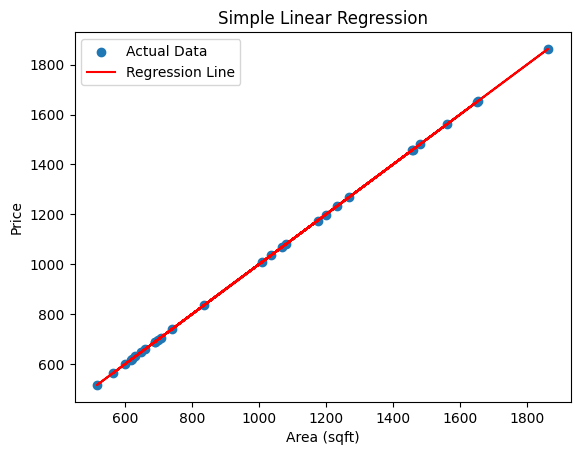

In [97]:
from sklearn.linear_model import LinearRegression

# Using only area_sqft
x_simple = house_pri[["area_sqft"]]
y = house_pri["area_sqft"]

# Training the model
model_li = LinearRegression()
model_li.fit(x_simple, y)

# Prediction
y_pred_simple = model_li.predict(x_simple)

# Plotting
plt.scatter(x_simple, y, label="Actual Data")
plt.plot(x_simple, y_pred_simple, color='red', label="Regression Line")
plt.xlabel("Area (sqft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.legend()

# Printing the intercept and coefficient
print("Intercept:", model_li.intercept_)
print("Coifficient:", model_li.coef_[0])

#### **b)** Train a Multiple Linear Regression model using all features. Print and compare: MAE, MSE, RMSE, R² Score, and Adjusted R² Score for both train and test sets. Comment on overfitting.

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Training model
model_li.fit(x_train, y_train)

# Predictions
y_train_pred = model_li.predict(x_train)
y_test_pred = model_li.predict(x_test)

# Using metrics
def evaluate(y_true, y_pred, x):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    n = x.shape[0]
    p = x.shape[1]
    
    return mae, mse, rmse, r2

# Get metrics
train_metrics = evaluate(y_train, y_train_pred, x_train)
test_metrics = evaluate(y_test, y_test_pred, x_test)

# Create comparison table
metrics_names = ["MAE", "MSE", "RMSE", "R²"]

df_results = pd.DataFrame({
    "Metric": metrics_names,
    "Train": train_metrics,
    "Test": test_metrics
})

# Print nicely
print(df_results)

  Metric         Train          Test
0    MAE  6.527630e+03  9.006698e+03
1    MSE  7.064799e+07  1.917508e+08
2   RMSE  8.405236e+03  1.384741e+04
3     R²  9.277980e-01  8.601724e-01


The model performs well with a high R² score on both training (0.93) and test (0.86) datasets, indicating strong explanatory power. Error metrics (MAE and RMSE) are higher on the test set, which is expected. The moderate gap between training and test performance suggests slight but acceptable overfitting, and overall the model generalizes well

#### **c)** Identify the top 3 most important features by examining the absolute values of regression coefficients (after scaling). Justify why these features make intuitive sense.

In [99]:
model_li.fit(x_train_scaled, y_train)

# Get coefficients
coefficients = model_li.coef_

# Create DataFrame
feature_importance = pd.DataFrame({
    "Feature": x_train_scaled.columns,
    "Coefficient": coefficients,
    "Absolute Value": np.abs(coefficients)
})

# Sort by importance
feature_importance = feature_importance.sort_values(by="Absolute Value", ascending=False)

# Top 3 features
top3 = feature_importance.head(3)
print(top3)

           Feature   Coefficient  Absolute Value
0        area_sqft  39822.756498    39822.756498
8   price_per_sqft  25674.788276    25674.788276
3  house_age_years -18618.341870    18618.341870


Area_sqft is important because larger houses generally have higher prices. Location_score is significant as properties in better locations are more valuable. Bathrooms/bedrooms influence price since more rooms increase usability and demand.

#### **d)** Plot residuals vs. fitted values for the Multiple Linear Regression. Does the model satisfy the homoscedasticity assumption? Briefly explain.

Text(0.5, 1.0, 'Residuals vs Fitted Values')

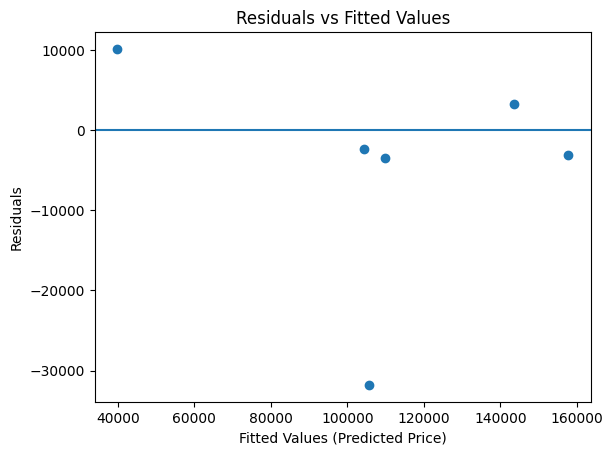

In [100]:
# Residuals (difference between actual and predicted)
residuals = y_test - y_test_pred

# Plot
plt.figure()
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Fitted Values (Predicted Price)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

#### **Q4 a)** Apply Polynomial Regression (degree=2 and degree=3) using area_sqft and location_score as features. Compare the R² scores of degree 1, 2, and 3 models on the test set. Plot all three curves on the same graph.

#### **b)** Implement Batch Gradient Descent manually (without sklearn) to find the optimal weights for a simple linear regression (one feature). Plot the cost (MSE) vs. iterations curve.

#### **c)** Using the sklearn SGDRegressor, demonstrate the effect of different learning rates (0.001, 0.01, 0.1) on convergence. Compare test RMSE for each. Explain Batch vs Stochastic vs Mini-Batch Gradient Descent in comments.